In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## CNN+Transformer without the adjencency map

In [ ]:
# =============================================================
# FULL PIPELINE FOR FI-2010 + TRANSLOBFORMER (CNN+transformer)
# (Updated for TXT file format and Z-Score Normalization)
# =============================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import math
import os
from tqdm import tqdm

TRAIN_FILE_PATH = "/content/drive/MyDrive/Colab Notebooks/Final_project/Train_Dst_NoAuction_ZScore_CF_9.txt" # Placeholder Name
TEST_FILE_PATH = "/content/drive/MyDrive/Colab Notebooks/Final_project/Test_Dst_NoAuction_ZScore_CF_9.txt"   # Placeholder Name
HORIZON_INDEX = 0 # Predict T+1
EPOCHS = 30
LAMBDA_CONTRASTIVE = 0.1
LEARNING_RATE = 1e-4
# ---------------------

# 1. READ DATA (DeepLOB TXT Loader)

def read_data_txt(path):
    data_list = []
    with open(path, 'r') as f:
        while True:
            line = f.readline()
            if not line:
                break
            d_str = line.split()
            # Only process if line is not empty
            if d_str:
                try:
                    d_tem = [float(d) for d in d_str]
                    data_list.append(d_tem)
                except ValueError:
                    # Skip lines that can't be parsed (e.g., malformed data)
                    continue
    data = pd.DataFrame(data_list)
    # The transpose (.T) is crucial because the raw data is (45 columns x T rows)
    # but the DeepLOB TXT format is usually (T rows x 45 columns) after parsing.
    # The original DeepLOB loader often expects data structured like (Time steps x Features)
    # but the original text files have rows = features and columns = time steps, hence the transpose.
    # We will rely on the structure implied by your Keras notebook:
    return data.T # We skip the .T if the input TXT file is already structured (T, C).
                # Let's rely on the downstream assertion to catch errors.

def load_all_assets(base_path_template, asset_ids=range(1, 10)):
    """
    Dynamically loads and concatenates dataframes for a range of asset IDs.

    Args:
        base_path_template (str): A template string for the file path,
                                  where '9' should be replaced by the asset ID.
        asset_ids (range): Range of asset IDs to load (e.g., 1 to 9).

    Returns:
        pd.DataFrame: A single DataFrame containing all assets concatenated.
    """
    all_data_frames = []

    for i in asset_ids:
        # Construct the file path by replacing the '9' in the template with the current asset ID 'i'
        # This assumes the template ends in '_9.txt'
        current_path = base_path_template.replace('_9.txt', f'_{i}.txt')

        try:
            df = read_data_txt(current_path)
            all_data_frames.append(df)
        except FileNotFoundError:
            print(f"Warning: File not found for asset {i} at: {current_path}")
        except Exception as e:
            print(f"Error loading asset {i}: {e}")

    if not all_data_frames:
        raise ValueError("No data files were loaded. Check paths and naming convention.")

    # Concatenate all DataFrames vertically (axis=0, stacking the time series)
    return pd.concat(all_data_frames, axis=0, ignore_index=True)


# 2. CONSTRUCT WINDOWS & Z-SCORE NORMALIZE

def make_transformer_data(
    df,
    sample_size=100,
    feature_num=40,
    target_num=5,
    horizon_index=2,
    scaler=None,
    fit_scaler=True
):

    data = df.values
    T, C = data.shape

    features = data[:, 0:feature_num]
    labels_all = data[:, -target_num:]

    # NORMALIZATION (Z-score)
    if fit_scaler:
        mean = features.mean(axis=0, keepdims=True)
        std = features.std(axis=0, keepdims=True)
        std[std == 0] = 1.0
        features = (features - mean) / std
        scaler = {'mean': mean, 'std': std}
    else:
        features = (features - scaler['mean']) / scaler['std']

    # Construct Windowed Data
    num_samples = T - sample_size
    X = np.zeros((num_samples, sample_size, 10, 4), dtype=np.float32)
    Y_all = np.zeros((num_samples, target_num), dtype=np.int64)

    for i in range(num_samples):
        window = features[i:i+sample_size, :]
        X[i] = window.reshape(sample_size, 10, 4)
        Y_all[i] = labels_all[i + sample_size - 1, :]

    Y_all = Y_all - 1      # shift 1,2,3 → 0,1,2 for 3-class classification
    y = Y_all[:, horizon_index]

    return X, y, scaler

# 3. DATASET + DATALOADER (Unchanged)

class LobDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# 4. TRANSFORMER MODEL WITH CONTRASTIVE CRITIC (Unchanged)

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).float().unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() *
                             (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div_term)
        pe[:, 1::2] = torch.cos(pos * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class SpatialEncoder(nn.Module):
    def __init__(self, n_features=4, hidden=32, d_spatial=64):
        super().__init__()
        self.conv1 = nn.Conv1d(n_features, hidden, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(hidden, hidden, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(hidden)
        self.bn2 = nn.BatchNorm1d(hidden)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(hidden, d_spatial)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.bn1(F.relu(self.conv1(x)))
        x = self.bn2(F.relu(self.conv2(x)))
        x = self.pool(x).squeeze(-1)
        return self.fc(x)


class TransLOBFormer(nn.Module):
    def __init__(
        self,
        d_model=32,
        d_spatial=64,
        nhead=4,
        num_layers=3,
        dim_feedforward=64,
        dropout=0.1,
        num_classes=3,
        max_seq_len=100,
        temperature=0.1,
    ):
        super().__init__()

        self.temperature = temperature
        self.d_model = d_model
        self.spatial = SpatialEncoder(d_spatial=d_spatial)
        self.proj = nn.Linear(d_spatial, d_model)

        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_encode = PositionalEncoding(d_model, max_seq_len + 1)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward, dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        self.mlp_head = nn.Sequential(
            nn.Linear(d_model, d_model), nn.ReLU(), nn.Dropout(dropout), nn.Linear(d_model, num_classes)
        )
        self.proj_x = nn.Linear(d_model, d_model)
        self.proj_z = nn.Linear(d_model, d_model)
        nn.init.normal_(self.cls_token, mean=0.0, std=0.02)

    def forward(self, x):
        B, T, L, Fdim = x.shape
        x_flat = x.reshape(B*T, L, Fdim)
        spatial = self.spatial(x_flat)
        tokens = self.proj(spatial).view(B, T, -1)

        cls = self.cls_token.expand(B, 1, -1)
        tokens = torch.cat([cls, tokens], dim=1)
        tokens = self.pos_encode(tokens)

        enc = self.transformer(tokens)
        cls_rep = enc[:, 0, :]
        pooled_tokens = enc[:, 1:, :].mean(dim=1)

        logits = self.mlp_head(cls_rep)
        return logits, cls_rep, pooled_tokens

    def contrastive_loss(self, cls_rep, pooled_tokens):
        z = F.normalize(self.proj_z(cls_rep), dim=-1)
        x = F.normalize(self.proj_x(pooled_tokens), dim=-1)

        logits = (z @ x.T) / self.temperature
        labels = torch.arange(len(z), device=z.device)
        return F.cross_entropy(logits, labels)

# 5. TRAINING STEP & 6. EVALUATION (Unchanged)

def train_step(model, xb, yb, optimizer, lambda_contrastive=0.1, device="cuda"):
    model.train()
    xb, yb = xb.to(device), yb.to(device)

    optimizer.zero_grad()
    logits, cls_rep, pooled_tokens = model(xb)

    ce_loss = F.cross_entropy(logits, yb)

    if len(cls_rep) > 1:
        con_loss = model.contrastive_loss(cls_rep, pooled_tokens)
    else:
        con_loss = torch.tensor(0.0, device=device)
        lambda_contrastive = 0.0

    total = ce_loss + lambda_contrastive * con_loss
    total.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    acc = (logits.argmax(dim=1) == yb).float().mean().item()

    return total.item(), ce_loss.item(), con_loss.item(), acc

def evaluate(model, loader, device="cuda"):
    model.eval()
    total_loss, total_correct, n = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits, _, _ = model(xb)
            loss = F.cross_entropy(logits, yb)
            preds = logits.argmax(dim=1)
            total_loss += loss.item() * yb.size(0)
            total_correct += (preds == yb).sum().item()
            n += yb.size(0)
    return total_loss / n, total_correct / n

TRAIN_FILE_PATH_TEMPLATE = "/content/drive/MyDrive/Colab Notebooks/Final_project/Train_Dst_NoAuction_ZScore_CF_9.txt"
TEST_FILE_PATH_TEMPLATE = "/content/drive/MyDrive/Colab Notebooks/Final_project/Test_Dst_NoAuction_ZScore_CF_9.txt"

device = "cuda" if torch.cuda.is_available() else "cpu"

print("\n--- 1. Reading and Concatenating All Assets (1-9) ---")

# Load and concatenate all 9 training assets
train_df = load_all_assets(TRAIN_FILE_PATH_TEMPLATE)
print(f"Total training time steps: {train_df.shape[0]}")

# Load and concatenate all 9 testing assets
test_df  = load_all_assets(TEST_FILE_PATH_TEMPLATE)
print(f"Total testing time steps: {test_df.shape[0]}")

# 2. Process and Normalize Data
train_X, train_y, scaler = make_transformer_data(
    train_df, horizon_index=HORIZON_INDEX, fit_scaler=True
)
test_X,  test_y, _ = make_transformer_data(
    test_df, horizon_index=HORIZON_INDEX, fit_scaler=False, scaler=scaler
)

# 3. DataLoaders
train_loader = DataLoader(LobDataset(train_X, train_y), batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(LobDataset(test_X, test_y), batch_size=BATCH_SIZE*2)

# 4. Model Setup
model = TransLOBFormer().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-2)

# Training Steps
print("\n--- Starting Training ---")
for epoch in range(1, EPOCHS + 1):
    tot_loss = tot_ce = tot_con = tot_acc = count = 0

    train_loop = tqdm(train_loader, desc=f"Epoch {epoch:02d}", leave=False)

    for xb, yb in train_loop:
        loss, ce, con, acc = train_step(model, xb, yb, optimizer,
                                        lambda_contrastive=LAMBDA_CONTRASTIVE, device=device)
        bs = yb.size(0)
        tot_loss += loss * bs
        tot_ce += ce * bs
        tot_con += con * bs
        tot_acc += acc * bs
        count += bs

        train_loop.set_postfix({
            'Acc': f'{acc:.3f}',
            'Loss': f'{loss:.4f}',
            'CE': f'{ce:.4f}',
            'Con': f'{con:.4f}'
        })

    print(f"Epoch {epoch:02d} | Train Loss {tot_loss/count:.4f} | Train Acc {tot_acc/count:.3f}")

    # Evaluation step
    if epoch % 1 == 0:
        val_loss, val_acc = evaluate(model, test_loader, device)
        print(f"--- Epoch {epoch:02d} Test Acc: {val_acc:.4f} ---")


# Final Result
print("\n--- Final Evaluation ---")
test_loss, test_acc = evaluate(model, test_loader, device)
print(f"Final Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_acc:.4f}")


--- 1. Reading and Concatenating All Assets (1-9) ---
Loaded asset 1 from: /content/drive/MyDrive/Colab Notebooks/Final_project/Train_Dst_NoAuction_ZScore_CF_1.txt
Loaded asset 2 from: /content/drive/MyDrive/Colab Notebooks/Final_project/Train_Dst_NoAuction_ZScore_CF_2.txt
Loaded asset 3 from: /content/drive/MyDrive/Colab Notebooks/Final_project/Train_Dst_NoAuction_ZScore_CF_3.txt
Loaded asset 4 from: /content/drive/MyDrive/Colab Notebooks/Final_project/Train_Dst_NoAuction_ZScore_CF_4.txt
Loaded asset 5 from: /content/drive/MyDrive/Colab Notebooks/Final_project/Train_Dst_NoAuction_ZScore_CF_5.txt
Loaded asset 6 from: /content/drive/MyDrive/Colab Notebooks/Final_project/Train_Dst_NoAuction_ZScore_CF_6.txt
Loaded asset 7 from: /content/drive/MyDrive/Colab Notebooks/Final_project/Train_Dst_NoAuction_ZScore_CF_7.txt
Loaded asset 8 from: /content/drive/MyDrive/Colab Notebooks/Final_project/Train_Dst_NoAuction_ZScore_CF_8.txt
Loaded asset 9 from: /content/drive/MyDrive/Colab Notebooks/Final

Epoch 01 | Train Loss 0.9739 | Train Acc 0.620
--- Epoch 01 Test Acc: 0.6442 ---


Epoch 02 | Train Loss 0.8600 | Train Acc 0.644
--- Epoch 02 Test Acc: 0.6889 ---


Epoch 03 | Train Loss 0.7791 | Train Acc 0.689
--- Epoch 03 Test Acc: 0.7326 ---


Epoch 04 | Train Loss 0.7273 | Train Acc 0.716
--- Epoch 04 Test Acc: 0.7457 ---


...

Epoch 24 | Train Loss 0.6222 | Train Acc 0.758
--- Epoch 24 Test Acc: 0.7747 ---


Epoch 25 | Train Loss 0.6209 | Train Acc 0.758
--- Epoch 25 Test Acc: 0.7754 ---


Epoch 26 | Train Loss 0.6192 | Train Acc 0.759
--- Epoch 26 Test Acc: 0.7762 ---


Epoch 27 | Train Loss 0.6178 | Train Acc 0.759
--- Epoch 27 Test Acc: 0.7763 ---


Epoch 28:  98%|█████████▊| 12991/13206 [05:20<00:05, 40.42it/s, Acc=0.688, Loss=0.7291, CE=0.7196, Con=0.0950]

## FULL PIPELINE FOR FI-2010 + CNN + transformer + adjacency map

In [ ]:
import os
import math
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import f1_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset, ConcatDataset

# --- Config ---
BASE_PATH = "/content/drive/MyDrive/Colab Notebooks/Final_project/"
ASSET_IDS = range(1, 10)
MODEL_SAVE_PATH = "best_combined_adj_model.pth"
SAMPLE_SIZE, FEATURE_NUM, TARGET_NUM, HORIZON_INDEX = 100, 40, 5, 4
BATCH_SIZE, EPOCHS, LEARNING_RATE, PATIENCE = 128, 30, 1e-4, 5  # Adjusted Epochs and Patience
LAMBDA_CONTRASTIVE, D_MODEL, D_SPATIAL = 0.1, 32, 64

# --- Data Handling ---
class AssetDataset(Dataset):
    def __init__(self, feats, labels, sample_size):
        self.feats, self.labels = torch.from_numpy(feats).float(), torch.from_numpy(labels).long()
        self.S = sample_size
    def __len__(self): return len(self.feats) - self.S
    def __getitem__(self, idx):
        return self.feats[idx:idx+self.S], self.labels[idx+self.S-1]

def load_and_combine_assets(asset_ids, mode="Train"):
    all_ds = []
    for aid in asset_ids:
        path = f"{BASE_PATH}{mode}_Dst_NoAuction_ZScore_CF_{aid}.txt"
        df = pd.read_csv(path, sep='\s+', header=None).T
        feats_raw = df.values[:, :FEATURE_NUM]
        labels = df.values[:, -TARGET_NUM + HORIZON_INDEX].astype(np.int64) - 1
        std = feats_raw.std(0, keepdims=True); std[std == 0] = 1.0
        feats = (feats_raw - feats_raw.mean(0, keepdims=True)) / std
        all_ds.append(AssetDataset(feats.reshape(-1, 10, 4).astype(np.float32), labels, SAMPLE_SIZE))
    return ConcatDataset(all_ds)

# --- Model Components ---
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).float().unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2], pe[:, 1::2] = torch.sin(pos * div), torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x): return x + self.pe[:, :x.size(1)]

class SpatialEncoder(nn.Module):
    def __init__(self, n_features=4, hidden=32, d_spatial=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(n_features, hidden, 3, padding=1), nn.BatchNorm1d(hidden), nn.ReLU(),
            nn.Conv1d(hidden, hidden, 3, padding=1), nn.BatchNorm1d(hidden), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.fc = nn.Linear(hidden, d_spatial)
    def forward(self, x): return self.fc(self.net(x.permute(0, 2, 1)).squeeze(-1))

class TransLOBFormerAdj(nn.Module):
    def __init__(self, d_model=32, d_spatial=64, nhead=4, num_layers=3, num_classes=3):
        super().__init__()
        self.d_model = d_model
        self.spatial = SpatialEncoder(d_spatial=d_spatial)
        self.proj = nn.Linear(d_spatial, d_model)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_encode = PositionalEncoding(d_model, SAMPLE_SIZE + 1)
        self.transformer = nn.TransformerEncoder(nn.TransformerEncoderLayer(d_model, nhead, batch_first=True), num_layers)
        self.inf_A = nn.Linear(d_model, d_model * 8); self.inf_B = nn.Linear(d_model, d_model * 8)
        self.head = nn.Sequential(nn.Linear(d_model, d_model), nn.ReLU(), nn.Linear(d_model, num_classes))
        self.proj_x, self.proj_z = nn.Linear(d_model, d_model), nn.Linear(d_model, d_model)
        nn.init.normal_(self.cls_token, std=0.02)

    def forward(self, x):
        B, S, L, Fdim = x.shape
        tokens = self.proj(self.spatial(x.reshape(B*S, L, Fdim))).view(B, S, -1)
        x = self.pos_encode(torch.cat((self.cls_token.expand(B, -1, -1), tokens), dim=1))
        feat = self.transformer(x); cls_rep = feat[:, 0, :]
        A, B_mat = self.inf_A(cls_rep).view(B, self.d_model, 8), self.inf_B(cls_rep).view(B, self.d_model, 8)
        adj = torch.sigmoid(torch.bmm(A, B_mat.transpose(1, 2)) / math.sqrt(8))
        adj = (adj + torch.eye(self.d_model, device=adj.device)) / (adj.sum(-1, keepdim=True) + 1e-6)
        cls_ref = cls_rep + 0.3 * torch.bmm(adj, cls_rep.unsqueeze(-1)).squeeze(-1)
        return self.head(cls_ref), cls_ref, feat[:, 1:, :].mean(dim=1)

    def contrastive_loss(self, cls_rep, pooled):
        z, x = F.normalize(self.proj_z(cls_rep), dim=-1), F.normalize(self.proj_x(pooled), dim=-1)
        return F.cross_entropy((z @ x.T) / 0.1, torch.arange(len(z), device=z.device))

# --- Training Utilities ---
def evaluate(model, loader, device):
    model.eval()
    t_loss, t_corr, n = 0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            out, _, _ = model(xb)
            t_loss += F.cross_entropy(out, yb).item() * yb.size(0)
            t_corr += (out.argmax(1) == yb).sum().item()
            n += yb.size(0)
    return t_loss/n, t_corr/n

# --- Main Logic ---
device = "cuda" if torch.cuda.is_available() else "cpu"
train_loader = DataLoader(load_and_combine_assets(ASSET_IDS, "Train"), BATCH_SIZE, shuffle=True)
test_full = load_and_combine_assets(ASSET_IDS, "Test")
mid = len(test_full) // 2
val_loader = DataLoader(Subset(test_full, range(0, mid)), BATCH_SIZE*2)
test_loader = DataLoader(Subset(test_full, range(mid, len(test_full))), BATCH_SIZE*2)

model = TransLOBFormerAdj().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-2)

print("\n--- Starting Training with Early Stopping ---")
best_acc, patience_counter = 0.0, 0



for epoch in range(1, EPOCHS + 1):
    model.train()
    tot_acc, count = 0, 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch:02d}", leave=False)
    for xb, yb in pbar:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out, cls, pooled = model(xb)
        loss = F.cross_entropy(out, yb) + LAMBDA_CONTRASTIVE * model.contrastive_loss(cls, pooled)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        acc = (out.argmax(1) == yb).float().mean().item()
        tot_acc += acc * yb.size(0); count += yb.size(0)
        pbar.set_postfix({'Acc': f'{acc:.3f}', 'Loss': f'{loss.item():.4f}'})

    v_loss, v_acc = evaluate(model, val_loader, device)
    # Tweak: Exact print format from your example
    print(f"Epoch {epoch:02d} | Train Acc {tot_acc/count:.3f} | Val Acc: {v_acc:.4f}")

    if v_acc > best_acc:
        best_acc, patience_counter = v_acc, 0
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
    else:
        patience_counter += 1
    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch}.")
        break

print("\n--- Final Evaluation ---")
if os.path.exists(MODEL_SAVE_PATH): model.load_state_dict(torch.load(MODEL_SAVE_PATH))
t_loss, t_acc = evaluate(model, test_loader, device)

# Tweak: Updated to show Final Test Accuracy clearly
print(f"Final Test Loss: {t_loss:.4f}")
print(f"Final Test Accuracy: {t_acc:.4f}")

--- Starting Training with Early Stopping ---
Epoch 01 | Train Acc 0.658 | Val Acc: 0.6503
Epoch 02 | Train Acc 0.685 | Val Acc: 0.6819
Epoch 03 | Train Acc 0.717 | Val Acc: 0.7037
Epoch 04 | Train Acc 0.736 | Val Acc: 0.7243
Epoch 05 | Train Acc 0.754 | Val Acc: 0.7461
Epoch 06 | Train Acc 0.766 | Val Acc: 0.7586
Epoch 07 | Train Acc 0.785 | Val Acc: 0.7725
Epoch 08 | Train Acc 0.791 | Val Acc: 0.7793
Epoch 09 | Train Acc 0.803 | Val Acc: 0.7910
Epoch 10 | Train Acc 0.807 | Val Acc: 0.7962
Epoch 11 | Train Acc 0.815 | Val Acc: 0.8039
Epoch 12 | Train Acc 0.820 | Val Acc: 0.8092
Epoch 13 | Train Acc 0.824 | Val Acc: 0.8123
Epoch 14 | Train Acc 0.828 | Val Acc: 0.8167
Epoch 15 | Train Acc 0.830 | Val Acc: 0.8195
Epoch 16 | Train Acc 0.833 | Val Acc: 0.8204
Epoch 17 | Train Acc 0.835 | Val Acc: 0.8236
Epoch 18 | Train Acc 0.837 | Val Acc: 0.8249
Epoch 19 | Train Acc 0.838 | Val Acc: 0.8264
Epoch 20 | Train Acc 0.840 | Val Acc: 0.8271
Epoch 21 | Train Acc 0.840 | Val Acc: 0.8286
Epoch 22 

## Below is the test case for some other time interval predictions which are unrelated to this paper

In [ ]:
# =============================================================

# (Updated for TXT format, All Assets, and Early Stopping)
# =============================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import math
import os
from tqdm import tqdm

# --- Configuration ---
# NOTE: Replace these paths with local paths where your files are accessible!
TRAIN_FILE_PATH_TEMPLATE = "/content/drive/MyDrive/Colab Notebooks/Final_project/Train_Dst_NoAuction_ZScore_CF_9.txt"
TEST_FILE_PATH_TEMPLATE = "/content/drive/MyDrive/Colab Notebooks/Final_project/Test_Dst_NoAuction_ZScore_CF_9.txt"
MODEL_SAVE_PATH = "best_model.pth" # File to save best model weights
HORIZON_INDEX = 0 # Predict k=1 (the first prediction period)
BATCH_SIZE = 128
EPOCHS = 20
LAMBDA_CONTRASTIVE = 0.1
LEARNING_RATE = 1e-4
PATIENCE = 3 # <--- NEW: Number of epochs to wait for improvement before stopping
# ---------------------

# =============================================================
# 1. READ DATA (DeepLOB TXT Loader)
# =============================================================

def read_data_txt(path):
    # ... (read_data_txt function is unchanged)
    data_list = []
    with open(path, 'r') as f:
        while True:
            line = f.readline()
            if not line:
                break
            d_str = line.split()
            if d_str:
                try:
                    d_tem = [float(d) for d in d_str]
                    data_list.append(d_tem)
                except ValueError:
                    continue
    data = pd.DataFrame(data_list)
    return data.T

def load_all_assets(base_path_template, asset_ids=range(1, 10)):
    # ... (load_all_assets function is unchanged)
    all_data_frames = []
    for i in asset_ids:
        current_path = base_path_template.replace('_9.txt', f'_{i}.txt')
        try:
            df = read_data_txt(current_path)
            all_data_frames.append(df)
        except:
            # print(f"Warning: File not found for asset {i} at: {current_path}")
            pass # Suppressed errors for cleaner VM output

    if not all_data_frames:
        raise ValueError("No data files were loaded. Check paths and naming convention.")

    return pd.concat(all_data_frames, axis=0, ignore_index=True)

# =============================================================
# 2. CONSTRUCT WINDOWS & Z-SCORE NORMALIZE
# =============================================================

def make_transformer_data(
    df,
    sample_size=100,
    feature_num=40,
    target_num=5,
    horizon_index=2,
    scaler=None,
    fit_scaler=True
):
    # ... (make_transformer_data function is unchanged)
    data = df.values
    T, C = data.shape
    features = data[:, 0:feature_num]
    labels_all = data[:, -target_num:]

    # NORMALIZATION (Z-score)
    if fit_scaler:
        mean = features.mean(axis=0, keepdims=True)
        std = features.std(axis=0, keepdims=True)
        std[std == 0] = 1.0
        features = (features - mean) / std
        scaler = {'mean': mean, 'std': std}
    else:
        features = (features - scaler['mean']) / scaler['std']

    # Construct Windowed Data
    num_samples = T - sample_size
    X = np.zeros((num_samples, sample_size, 10, 4), dtype=np.float32)
    Y_all = np.zeros((num_samples, target_num), dtype=np.int64)

    for i in range(num_samples):
        window = features[i:i+sample_size, :]
        X[i] = window.reshape(sample_size, 10, 4)
        Y_all[i] = labels_all[i + sample_size - 1, :]

    Y_all = Y_all - 1
    y = Y_all[:, horizon_index]

    return X, y, scaler

# =============================================================
# 3. DATASET + DATALOADER, 4. MODEL, 5. TRAIN/EVAL FUNCTIONS
# (Unchanged for brevity, assumed to be correct)
# =============================================================

class LobDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class PositionalEncoding(nn.Module):
    # ... (implementation unchanged)
    def __init__(self, d_model, max_len=1000):
        super().__init__(); pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).float().unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div_term); pe[:, 1::2] = torch.cos(pos * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x): return x + self.pe[:, :x.size(1), :]

class SpatialEncoder(nn.Module):
    # ... (implementation unchanged)
    def __init__(self, n_features=4, hidden=32, d_spatial=64):
        super().__init__()
        self.conv1 = nn.Conv1d(n_features, hidden, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(hidden, hidden, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(hidden); self.bn2 = nn.BatchNorm1d(hidden)
        self.pool = nn.AdaptiveAvgPool1d(1); self.fc = nn.Linear(hidden, d_spatial)
    def forward(self, x):
        x = x.permute(0, 2, 1); x = self.bn1(F.relu(self.conv1(x)))
        x = self.bn2(F.relu(self.conv2(x))); x = self.pool(x).squeeze(-1)
        return self.fc(x)

class TransLOBFormer(nn.Module):
    # ... (implementation unchanged)
    def __init__(self, d_model=32, d_spatial=64, nhead=4, num_layers=3, dim_feedforward=64, dropout=0.1, num_classes=3, max_seq_len=100, temperature=0.1):
        super().__init__(); self.temperature = temperature; self.d_model = d_model
        self.spatial = SpatialEncoder(d_spatial=d_spatial); self.proj = nn.Linear(d_spatial, d_model)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_encode = PositionalEncoding(d_model, max_seq_len + 1)
        enc_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward, dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.mlp_head = nn.Sequential(nn.Linear(d_model, d_model), nn.ReLU(), nn.Dropout(dropout), nn.Linear(d_model, num_classes))
        self.proj_x = nn.Linear(d_model, d_model); self.proj_z = nn.Linear(d_model, d_model)
        nn.init.normal_(self.cls_token, mean=0.0, std=0.02)
    def forward(self, x):
        B, T, L, Fdim = x.shape; x_flat = x.reshape(B*T, L, Fdim)
        spatial = self.spatial(x_flat); tokens = self.proj(spatial).view(B, T, -1)
        cls = self.cls_token.expand(B, 1, -1); tokens = torch.cat([cls, tokens], dim=1)
        tokens = self.pos_encode(tokens); enc = self.transformer(tokens)
        cls_rep = enc[:, 0, :]; pooled_tokens = enc[:, 1:, :].mean(dim=1)
        logits = self.mlp_head(cls_rep); return logits, cls_rep, pooled_tokens
    def contrastive_loss(self, cls_rep, pooled_tokens):
        z = F.normalize(self.proj_z(cls_rep), dim=-1); x = F.normalize(self.proj_x(pooled_tokens), dim=-1)
        logits = (z @ x.T) / self.temperature; labels = torch.arange(len(z), device=z.device)
        return F.cross_entropy(logits, labels)

def train_step(model, xb, yb, optimizer, lambda_contrastive=0.1, device="cuda"):
    # ... (train_step implementation unchanged)
    model.train(); xb, yb = xb.to(device), yb.to(device); optimizer.zero_grad()
    logits, cls_rep, pooled_tokens = model(xb); ce_loss = F.cross_entropy(logits, yb)
    if len(cls_rep) > 1: con_loss = model.contrastive_loss(cls_rep, pooled_tokens)
    else: con_loss = torch.tensor(0.0, device=device); lambda_contrastive = 0.0
    total = ce_loss + lambda_contrastive * con_loss; total.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); optimizer.step()
    acc = (logits.argmax(dim=1) == yb).float().mean().item()
    return total.item(), ce_loss.item(), con_loss.item(), acc

def evaluate(model, loader, device="cuda"):
    # ... (evaluate implementation unchanged)
    model.eval(); total_loss, total_correct, n = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device); logits, _, _ = model(xb)
            loss = F.cross_entropy(logits, yb)
            preds = logits.argmax(dim=1)
            total_loss += loss.item() * yb.size(0)
            total_correct += (preds == yb).sum().item(); n += yb.size(0)
    return total_loss / n, total_correct / n

# =============================================================
# 7. EXAMPLE USAGE (Final Execution Block) - MODIFIED FOR EARLY STOPPING
# =============================================================

device = "cuda" if torch.cuda.is_available() else "cpu"

# 1. Read Data
train_df = load_all_assets(TRAIN_FILE_PATH_TEMPLATE)
full_test_df  = load_all_assets(TEST_FILE_PATH_TEMPLATE)

# 2. Process and Normalize Data
train_X, train_y, scaler = make_transformer_data(
    train_df, horizon_index=HORIZON_INDEX, fit_scaler=True
)
full_test_X, full_test_y, _ = make_transformer_data(
    full_test_df, horizon_index=HORIZON_INDEX, fit_scaler=False, scaler=scaler
)

# --- NEW: Split Data for Validation and Final Testing ---
split_idx = full_test_X.shape[0] // 2
val_X, val_y = full_test_X[:split_idx], full_test_y[:split_idx]
test_X, test_y = full_test_X[split_idx:], full_test_y[split_idx:]

# 3. DataLoaders
train_loader = DataLoader(LobDataset(train_X, train_y), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(LobDataset(val_X, val_y), batch_size=BATCH_SIZE*2)
test_loader  = DataLoader(LobDataset(test_X, test_y), batch_size=BATCH_SIZE*2)

# 4. Model Setup
model = TransLOBFormer().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-2)

# =============================================================
# Training Steps with Early Stopping
# =============================================================
print("\n--- Starting Training with Early Stopping ---")
best_val_acc = 0.0
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    tot_loss = tot_ce = tot_con = tot_acc = count = 0

    # Training Loop
    train_loop = tqdm(train_loader, desc=f"Epoch {epoch:02d}", leave=False)
    for xb, yb in train_loop:
        loss, ce, con, acc = train_step(model, xb, yb, optimizer,
                                        lambda_contrastive=LAMBDA_CONTRASTIVE, device=device)
        bs = yb.size(0)
        tot_loss += loss * bs
        tot_ce += ce * bs
        tot_con += con * bs
        tot_acc += acc * bs
        count += bs
        train_loop.set_postfix({'Acc': f'{acc:.3f}', 'Loss': f'{loss:.4f}'})

    # Validation step
    val_loss, val_acc = evaluate(model, val_loader, device)

    print(f"Epoch {epoch:02d} | Train Acc {tot_acc/count:.3f} | Val Acc: {val_acc:.4f}")

    # Early Stopping Logic (based on Accuracy)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        # Save the best model state
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        # print(f"Model saved! Best Val Acc: {best_val_acc:.4f}")
    else:
        patience_counter += 1
        # print(f"Validation Acc did not improve. Patience: {patience_counter}/{PATIENCE}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping triggered after {epoch} epochs.")
        break

# =============================================================
# Final Result (Load best model before final test)
# =============================================================
print("\n--- Final Evaluation ---")

# Load the best model weights found during training
if os.path.exists(MODEL_SAVE_PATH):
    model.load_state_dict(torch.load(MODEL_SAVE_PATH))
    # print("Loaded best model weights.")
else:
    # This will only print if the model was never saved (e.g., failed on epoch 1)
    pass

test_loss, test_acc = evaluate(model, test_loader, device)
print(f"Final Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_acc:.4f}")


--- Starting Training with Early Stopping ---


Epoch 01 | Train Acc 0.620 | Val Acc: 0.6133


Epoch 02 | Train Acc 0.654 | Val Acc: 0.6721


Epoch 03 | Train Acc 0.707 | Val Acc: 0.7159


Epoch 04 | Train Acc 0.726 | Val Acc: 0.7258


...

Epoch 26 | Train Acc 0.756 | Val Acc: 0.7522


Epoch 27 | Train Acc 0.756 | Val Acc: 0.7528


Epoch 28 | Train Acc 0.757 | Val Acc: 0.7532


Epoch 29 | Train Acc 0.758 | Val Acc: 0.7541


Epoch 30 | Train Acc 0.758 | Val Acc: 0.7543

--- Final Evaluation ---
Final Test Loss: 0.5418
Final Test Accuracy: 0.7933


In [ ]:
# =============================================================
# FULL PIPELINE FOR FI-2010 + TRANSLOBFORMER + CONTRASTIVE CRITIC
# (Updated for TXT format, All Assets, and Early Stopping)
# =============================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import math
import os
from tqdm import tqdm

# --- Configuration ---
# NOTE: Replace these paths with local paths where your files are accessible!
TRAIN_FILE_PATH_TEMPLATE = "/content/drive/MyDrive/Colab Notebooks/Final_project/Train_Dst_NoAuction_ZScore_CF_9.txt"
TEST_FILE_PATH_TEMPLATE = "/content/drive/MyDrive/Colab Notebooks/Final_project/Test_Dst_NoAuction_ZScore_CF_9.txt"
MODEL_SAVE_PATH = "best_model.pth" # File to save best model weights
HORIZON_INDEX = 1 # Predict k=1 (the first prediction period)
BATCH_SIZE = 128
EPOCHS = 20
LAMBDA_CONTRASTIVE = 0.1
LEARNING_RATE = 1e-4
PATIENCE = 3 # <--- NEW: Number of epochs to wait for improvement before stopping
# ---------------------

# =============================================================
# 1. READ DATA (DeepLOB TXT Loader)
# =============================================================

def read_data_txt(path):
    # ... (read_data_txt function is unchanged)
    data_list = []
    with open(path, 'r') as f:
        while True:
            line = f.readline()
            if not line:
                break
            d_str = line.split()
            if d_str:
                try:
                    d_tem = [float(d) for d in d_str]
                    data_list.append(d_tem)
                except ValueError:
                    continue
    data = pd.DataFrame(data_list)
    return data.T

def load_all_assets(base_path_template, asset_ids=range(1, 10)):
    # ... (load_all_assets function is unchanged)
    all_data_frames = []
    for i in asset_ids:
        current_path = base_path_template.replace('_9.txt', f'_{i}.txt')
        try:
            df = read_data_txt(current_path)
            all_data_frames.append(df)
        except:
            # print(f"Warning: File not found for asset {i} at: {current_path}")
            pass # Suppressed errors for cleaner VM output

    if not all_data_frames:
        raise ValueError("No data files were loaded. Check paths and naming convention.")

    return pd.concat(all_data_frames, axis=0, ignore_index=True)

# =============================================================
# 2. CONSTRUCT WINDOWS & Z-SCORE NORMALIZE
# =============================================================

def make_transformer_data(
    df,
    sample_size=100,
    feature_num=40,
    target_num=5,
    horizon_index=2,
    scaler=None,
    fit_scaler=True
):
    # ... (make_transformer_data function is unchanged)
    data = df.values
    T, C = data.shape
    features = data[:, 0:feature_num]
    labels_all = data[:, -target_num:]

    # NORMALIZATION (Z-score)
    if fit_scaler:
        mean = features.mean(axis=0, keepdims=True)
        std = features.std(axis=0, keepdims=True)
        std[std == 0] = 1.0
        features = (features - mean) / std
        scaler = {'mean': mean, 'std': std}
    else:
        features = (features - scaler['mean']) / scaler['std']

    # Construct Windowed Data
    num_samples = T - sample_size
    X = np.zeros((num_samples, sample_size, 10, 4), dtype=np.float32)
    Y_all = np.zeros((num_samples, target_num), dtype=np.int64)

    for i in range(num_samples):
        window = features[i:i+sample_size, :]
        X[i] = window.reshape(sample_size, 10, 4)
        Y_all[i] = labels_all[i + sample_size - 1, :]

    Y_all = Y_all - 1
    y = Y_all[:, horizon_index]

    return X, y, scaler

# =============================================================
# 3. DATASET + DATALOADER, 4. MODEL, 5. TRAIN/EVAL FUNCTIONS
# (Unchanged for brevity, assumed to be correct)
# =============================================================

class LobDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class PositionalEncoding(nn.Module):
    # ... (implementation unchanged)
    def __init__(self, d_model, max_len=1000):
        super().__init__(); pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).float().unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div_term); pe[:, 1::2] = torch.cos(pos * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x): return x + self.pe[:, :x.size(1), :]

class SpatialEncoder(nn.Module):
    # ... (implementation unchanged)
    def __init__(self, n_features=4, hidden=32, d_spatial=64):
        super().__init__()
        self.conv1 = nn.Conv1d(n_features, hidden, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(hidden, hidden, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(hidden); self.bn2 = nn.BatchNorm1d(hidden)
        self.pool = nn.AdaptiveAvgPool1d(1); self.fc = nn.Linear(hidden, d_spatial)
    def forward(self, x):
        x = x.permute(0, 2, 1); x = self.bn1(F.relu(self.conv1(x)))
        x = self.bn2(F.relu(self.conv2(x))); x = self.pool(x).squeeze(-1)
        return self.fc(x)

class TransLOBFormer(nn.Module):
    # ... (implementation unchanged)
    def __init__(self, d_model=32, d_spatial=64, nhead=4, num_layers=3, dim_feedforward=64, dropout=0.1, num_classes=3, max_seq_len=100, temperature=0.1):
        super().__init__(); self.temperature = temperature; self.d_model = d_model
        self.spatial = SpatialEncoder(d_spatial=d_spatial); self.proj = nn.Linear(d_spatial, d_model)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_encode = PositionalEncoding(d_model, max_seq_len + 1)
        enc_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward, dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.mlp_head = nn.Sequential(nn.Linear(d_model, d_model), nn.ReLU(), nn.Dropout(dropout), nn.Linear(d_model, num_classes))
        self.proj_x = nn.Linear(d_model, d_model); self.proj_z = nn.Linear(d_model, d_model)
        nn.init.normal_(self.cls_token, mean=0.0, std=0.02)
    def forward(self, x):
        B, T, L, Fdim = x.shape; x_flat = x.reshape(B*T, L, Fdim)
        spatial = self.spatial(x_flat); tokens = self.proj(spatial).view(B, T, -1)
        cls = self.cls_token.expand(B, 1, -1); tokens = torch.cat([cls, tokens], dim=1)
        tokens = self.pos_encode(tokens); enc = self.transformer(tokens)
        cls_rep = enc[:, 0, :]; pooled_tokens = enc[:, 1:, :].mean(dim=1)
        logits = self.mlp_head(cls_rep); return logits, cls_rep, pooled_tokens
    def contrastive_loss(self, cls_rep, pooled_tokens):
        z = F.normalize(self.proj_z(cls_rep), dim=-1); x = F.normalize(self.proj_x(pooled_tokens), dim=-1)
        logits = (z @ x.T) / self.temperature; labels = torch.arange(len(z), device=z.device)
        return F.cross_entropy(logits, labels)

def train_step(model, xb, yb, optimizer, lambda_contrastive=0.1, device="cuda"):
    # ... (train_step implementation unchanged)
    model.train(); xb, yb = xb.to(device), yb.to(device); optimizer.zero_grad()
    logits, cls_rep, pooled_tokens = model(xb); ce_loss = F.cross_entropy(logits, yb)
    if len(cls_rep) > 1: con_loss = model.contrastive_loss(cls_rep, pooled_tokens)
    else: con_loss = torch.tensor(0.0, device=device); lambda_contrastive = 0.0
    total = ce_loss + lambda_contrastive * con_loss; total.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); optimizer.step()
    acc = (logits.argmax(dim=1) == yb).float().mean().item()
    return total.item(), ce_loss.item(), con_loss.item(), acc

def evaluate(model, loader, device="cuda"):
    # ... (evaluate implementation unchanged)
    model.eval(); total_loss, total_correct, n = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device); logits, _, _ = model(xb)
            loss = F.cross_entropy(logits, yb)
            preds = logits.argmax(dim=1)
            total_loss += loss.item() * yb.size(0)
            total_correct += (preds == yb).sum().item(); n += yb.size(0)
    return total_loss / n, total_correct / n

# =============================================================
# 7. EXAMPLE USAGE (Final Execution Block) - MODIFIED FOR EARLY STOPPING
# =============================================================

device = "cuda" if torch.cuda.is_available() else "cpu"

# 1. Read Data
train_df = load_all_assets(TRAIN_FILE_PATH_TEMPLATE)
full_test_df  = load_all_assets(TEST_FILE_PATH_TEMPLATE)

# 2. Process and Normalize Data
train_X, train_y, scaler = make_transformer_data(
    train_df, horizon_index=HORIZON_INDEX, fit_scaler=True
)
full_test_X, full_test_y, _ = make_transformer_data(
    full_test_df, horizon_index=HORIZON_INDEX, fit_scaler=False, scaler=scaler
)

# --- NEW: Split Data for Validation and Final Testing ---
split_idx = full_test_X.shape[0] // 2
val_X, val_y = full_test_X[:split_idx], full_test_y[:split_idx]
test_X, test_y = full_test_X[split_idx:], full_test_y[split_idx:]

# 3. DataLoaders
train_loader = DataLoader(LobDataset(train_X, train_y), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(LobDataset(val_X, val_y), batch_size=BATCH_SIZE*2)
test_loader  = DataLoader(LobDataset(test_X, test_y), batch_size=BATCH_SIZE*2)

# 4. Model Setup
model = TransLOBFormer().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-2)

# =============================================================
# Training Steps with Early Stopping
# =============================================================
print("\n--- Starting Training with Early Stopping ---")
best_val_acc = 0.0
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    tot_loss = tot_ce = tot_con = tot_acc = count = 0

    # Training Loop
    train_loop = tqdm(train_loader, desc=f"Epoch {epoch:02d}", leave=False)
    for xb, yb in train_loop:
        loss, ce, con, acc = train_step(model, xb, yb, optimizer,
                                        lambda_contrastive=LAMBDA_CONTRASTIVE, device=device)
        bs = yb.size(0)
        tot_loss += loss * bs
        tot_ce += ce * bs
        tot_con += con * bs
        tot_acc += acc * bs
        count += bs
        train_loop.set_postfix({'Acc': f'{acc:.3f}', 'Loss': f'{loss:.4f}'})

    # Validation step
    val_loss, val_acc = evaluate(model, val_loader, device)

    print(f"Epoch {epoch:02d} | Train Acc {tot_acc/count:.3f} | Val Acc: {val_acc:.4f}")

    # Early Stopping Logic (based on Accuracy)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        # Save the best model state
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        # print(f"Model saved! Best Val Acc: {best_val_acc:.4f}")
    else:
        patience_counter += 1
        # print(f"Validation Acc did not improve. Patience: {patience_counter}/{PATIENCE}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping triggered after {epoch} epochs.")
        break

# =============================================================
# Final Result (Load best model before final test)
# =============================================================
print("\n--- Final Evaluation ---")

# Load the best model weights found during training
if os.path.exists(MODEL_SAVE_PATH):
    model.load_state_dict(torch.load(MODEL_SAVE_PATH))
    # print("Loaded best model weights.")
else:
    # This will only print if the model was never saved (e.g., failed on epoch 1)
    pass

test_loss, test_acc = evaluate(model, test_loader, device)
print(f"Final Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_acc:.4f}")


--- Starting Training with Early Stopping ---


Epoch 01 | Train Acc 0.516 | Val Acc: 0.5051


Epoch 02 | Train Acc 0.564 | Val Acc: 0.5931


Epoch 03 | Train Acc 0.611 | Val Acc: 0.6088


Epoch 04 | Train Acc 0.621 | Val Acc: 0.6148


...

Epoch 16 | Train Acc 0.654 | Val Acc: 0.6485


Epoch 17 | Train Acc 0.655 | Val Acc: 0.6492


Epoch 18 | Train Acc 0.656 | Val Acc: 0.6498


Epoch 19 | Train Acc 0.657 | Val Acc: 0.6513


Epoch 20 | Train Acc 0.658 | Val Acc: 0.6528

--- Final Evaluation ---
Final Test Loss: 0.7231
Final Test Accuracy: 0.7016


In [ ]:
# =============================================================
# FULL PIPELINE FOR FI-2010 + TRANSLOBFORMER + CONTRASTIVE CRITIC
# (Updated for TXT format, All Assets, and Early Stopping)
# =============================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import math
import os
from tqdm import tqdm

# --- Configuration ---
# NOTE: Replace these paths with local paths where your files are accessible!
TRAIN_FILE_PATH_TEMPLATE = "/content/drive/MyDrive/Colab Notebooks/Final_project/Train_Dst_NoAuction_ZScore_CF_9.txt"
TEST_FILE_PATH_TEMPLATE = "/content/drive/MyDrive/Colab Notebooks/Final_project/Test_Dst_NoAuction_ZScore_CF_9.txt"
MODEL_SAVE_PATH = "best_model.pth" # File to save best model weights
HORIZON_INDEX = 3 # Predict k=1 (the first prediction period)
BATCH_SIZE = 128
EPOCHS = 20
LAMBDA_CONTRASTIVE = 0.1
LEARNING_RATE = 1e-4
PATIENCE = 3 # <--- NEW: Number of epochs to wait for improvement before stopping
# ---------------------

# =============================================================
# 1. READ DATA (DeepLOB TXT Loader)
# =============================================================

def read_data_txt(path):
    # ... (read_data_txt function is unchanged)
    data_list = []
    with open(path, 'r') as f:
        while True:
            line = f.readline()
            if not line:
                break
            d_str = line.split()
            if d_str:
                try:
                    d_tem = [float(d) for d in d_str]
                    data_list.append(d_tem)
                except ValueError:
                    continue
    data = pd.DataFrame(data_list)
    return data.T

def load_all_assets(base_path_template, asset_ids=range(1, 10)):
    # ... (load_all_assets function is unchanged)
    all_data_frames = []
    for i in asset_ids:
        current_path = base_path_template.replace('_9.txt', f'_{i}.txt')
        try:
            df = read_data_txt(current_path)
            all_data_frames.append(df)
        except:
            # print(f"Warning: File not found for asset {i} at: {current_path}")
            pass # Suppressed errors for cleaner VM output

    if not all_data_frames:
        raise ValueError("No data files were loaded. Check paths and naming convention.")

    return pd.concat(all_data_frames, axis=0, ignore_index=True)

# =============================================================
# 2. CONSTRUCT WINDOWS & Z-SCORE NORMALIZE
# =============================================================

def make_transformer_data(
    df,
    sample_size=100,
    feature_num=40,
    target_num=5,
    horizon_index=2,
    scaler=None,
    fit_scaler=True
):
    # ... (make_transformer_data function is unchanged)
    data = df.values
    T, C = data.shape
    features = data[:, 0:feature_num]
    labels_all = data[:, -target_num:]

    # NORMALIZATION (Z-score)
    if fit_scaler:
        mean = features.mean(axis=0, keepdims=True)
        std = features.std(axis=0, keepdims=True)
        std[std == 0] = 1.0
        features = (features - mean) / std
        scaler = {'mean': mean, 'std': std}
    else:
        features = (features - scaler['mean']) / scaler['std']

    # Construct Windowed Data
    num_samples = T - sample_size
    X = np.zeros((num_samples, sample_size, 10, 4), dtype=np.float32)
    Y_all = np.zeros((num_samples, target_num), dtype=np.int64)

    for i in range(num_samples):
        window = features[i:i+sample_size, :]
        X[i] = window.reshape(sample_size, 10, 4)
        Y_all[i] = labels_all[i + sample_size - 1, :]

    Y_all = Y_all - 1
    y = Y_all[:, horizon_index]

    return X, y, scaler

# =============================================================
# 3. DATASET + DATALOADER, 4. MODEL, 5. TRAIN/EVAL FUNCTIONS
# (Unchanged for brevity, assumed to be correct)
# =============================================================

class LobDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class PositionalEncoding(nn.Module):
    # ... (implementation unchanged)
    def __init__(self, d_model, max_len=1000):
        super().__init__(); pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).float().unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div_term); pe[:, 1::2] = torch.cos(pos * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x): return x + self.pe[:, :x.size(1), :]

class SpatialEncoder(nn.Module):
    # ... (implementation unchanged)
    def __init__(self, n_features=4, hidden=32, d_spatial=64):
        super().__init__()
        self.conv1 = nn.Conv1d(n_features, hidden, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(hidden, hidden, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(hidden); self.bn2 = nn.BatchNorm1d(hidden)
        self.pool = nn.AdaptiveAvgPool1d(1); self.fc = nn.Linear(hidden, d_spatial)
    def forward(self, x):
        x = x.permute(0, 2, 1); x = self.bn1(F.relu(self.conv1(x)))
        x = self.bn2(F.relu(self.conv2(x))); x = self.pool(x).squeeze(-1)
        return self.fc(x)

class TransLOBFormer(nn.Module):
    # ... (implementation unchanged)
    def __init__(self, d_model=32, d_spatial=64, nhead=4, num_layers=3, dim_feedforward=64, dropout=0.1, num_classes=3, max_seq_len=100, temperature=0.1):
        super().__init__(); self.temperature = temperature; self.d_model = d_model
        self.spatial = SpatialEncoder(d_spatial=d_spatial); self.proj = nn.Linear(d_spatial, d_model)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_encode = PositionalEncoding(d_model, max_seq_len + 1)
        enc_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward, dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.mlp_head = nn.Sequential(nn.Linear(d_model, d_model), nn.ReLU(), nn.Dropout(dropout), nn.Linear(d_model, num_classes))
        self.proj_x = nn.Linear(d_model, d_model); self.proj_z = nn.Linear(d_model, d_model)
        nn.init.normal_(self.cls_token, mean=0.0, std=0.02)
    def forward(self, x):
        B, T, L, Fdim = x.shape; x_flat = x.reshape(B*T, L, Fdim)
        spatial = self.spatial(x_flat); tokens = self.proj(spatial).view(B, T, -1)
        cls = self.cls_token.expand(B, 1, -1); tokens = torch.cat([cls, tokens], dim=1)
        tokens = self.pos_encode(tokens); enc = self.transformer(tokens)
        cls_rep = enc[:, 0, :]; pooled_tokens = enc[:, 1:, :].mean(dim=1)
        logits = self.mlp_head(cls_rep); return logits, cls_rep, pooled_tokens
    def contrastive_loss(self, cls_rep, pooled_tokens):
        z = F.normalize(self.proj_z(cls_rep), dim=-1); x = F.normalize(self.proj_x(pooled_tokens), dim=-1)
        logits = (z @ x.T) / self.temperature; labels = torch.arange(len(z), device=z.device)
        return F.cross_entropy(logits, labels)

def train_step(model, xb, yb, optimizer, lambda_contrastive=0.1, device="cuda"):
    # ... (train_step implementation unchanged)
    model.train(); xb, yb = xb.to(device), yb.to(device); optimizer.zero_grad()
    logits, cls_rep, pooled_tokens = model(xb); ce_loss = F.cross_entropy(logits, yb)
    if len(cls_rep) > 1: con_loss = model.contrastive_loss(cls_rep, pooled_tokens)
    else: con_loss = torch.tensor(0.0, device=device); lambda_contrastive = 0.0
    total = ce_loss + lambda_contrastive * con_loss; total.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); optimizer.step()
    acc = (logits.argmax(dim=1) == yb).float().mean().item()
    return total.item(), ce_loss.item(), con_loss.item(), acc

def evaluate(model, loader, device="cuda"):
    # ... (evaluate implementation unchanged)
    model.eval(); total_loss, total_correct, n = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device); logits, _, _ = model(xb)
            loss = F.cross_entropy(logits, yb)
            preds = logits.argmax(dim=1)
            total_loss += loss.item() * yb.size(0)
            total_correct += (preds == yb).sum().item(); n += yb.size(0)
    return total_loss / n, total_correct / n

# =============================================================
# 7. EXAMPLE USAGE (Final Execution Block) - MODIFIED FOR EARLY STOPPING
# =============================================================

device = "cuda" if torch.cuda.is_available() else "cpu"

# 1. Read Data
train_df = load_all_assets(TRAIN_FILE_PATH_TEMPLATE)
full_test_df  = load_all_assets(TEST_FILE_PATH_TEMPLATE)

# 2. Process and Normalize Data
train_X, train_y, scaler = make_transformer_data(
    train_df, horizon_index=HORIZON_INDEX, fit_scaler=True
)
full_test_X, full_test_y, _ = make_transformer_data(
    full_test_df, horizon_index=HORIZON_INDEX, fit_scaler=False, scaler=scaler
)

# --- NEW: Split Data for Validation and Final Testing ---
split_idx = full_test_X.shape[0] // 2
val_X, val_y = full_test_X[:split_idx], full_test_y[:split_idx]
test_X, test_y = full_test_X[split_idx:], full_test_y[split_idx:]

# 3. DataLoaders
train_loader = DataLoader(LobDataset(train_X, train_y), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(LobDataset(val_X, val_y), batch_size=BATCH_SIZE*2)
test_loader  = DataLoader(LobDataset(test_X, test_y), batch_size=BATCH_SIZE*2)

# 4. Model Setup
model = TransLOBFormer().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-2)

# =============================================================
# Training Steps with Early Stopping
# =============================================================
print("\n--- Starting Training with Early Stopping ---")
best_val_acc = 0.0
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    tot_loss = tot_ce = tot_con = tot_acc = count = 0

    # Training Loop
    train_loop = tqdm(train_loader, desc=f"Epoch {epoch:02d}", leave=False)
    for xb, yb in train_loop:
        loss, ce, con, acc = train_step(model, xb, yb, optimizer,
                                        lambda_contrastive=LAMBDA_CONTRASTIVE, device=device)
        bs = yb.size(0)
        tot_loss += loss * bs
        tot_ce += ce * bs
        tot_con += con * bs
        tot_acc += acc * bs
        count += bs
        train_loop.set_postfix({'Acc': f'{acc:.3f}', 'Loss': f'{loss:.4f}'})

    # Validation step
    val_loss, val_acc = evaluate(model, val_loader, device)

    print(f"Epoch {epoch:02d} | Train Acc {tot_acc/count:.3f} | Val Acc: {val_acc:.4f}")

    # Early Stopping Logic (based on Accuracy)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        # Save the best model state
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        # print(f"Model saved! Best Val Acc: {best_val_acc:.4f}")
    else:
        patience_counter += 1
        # print(f"Validation Acc did not improve. Patience: {patience_counter}/{PATIENCE}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping triggered after {epoch} epochs.")
        break

# =============================================================
# Final Result (Load best model before final test)
# =============================================================
print("\n--- Final Evaluation ---")

# Load the best model weights found during training
if os.path.exists(MODEL_SAVE_PATH):
    model.load_state_dict(torch.load(MODEL_SAVE_PATH))
    # print("Loaded best model weights.")
else:
    # This will only print if the model was never saved (e.g., failed on epoch 1)
    pass

test_loss, test_acc = evaluate(model, test_loader, device)
print(f"Final Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_acc:.4f}")


--- Starting Training with Early Stopping ---


Epoch 01 | Train Acc 0.468 | Val Acc: 0.5701


Epoch 02 | Train Acc 0.599 | Val Acc: 0.6115


Epoch 03 | Train Acc 0.629 | Val Acc: 0.6367


Epoch 04 | Train Acc 0.646 | Val Acc: 0.6494


...

Epoch 16 | Train Acc 0.712 | Val Acc: 0.7150


Epoch 17 | Train Acc 0.714 | Val Acc: 0.7173


Epoch 18 | Train Acc 0.716 | Val Acc: 0.7170


Epoch 19 | Train Acc 0.718 | Val Acc: 0.7190


Epoch 20 | Train Acc 0.720 | Val Acc: 0.7204

--- Final Evaluation ---
Final Test Loss: 0.7204
Final Test Accuracy: 0.7086


In [ ]:
# =============================================================
# FULL PIPELINE FOR FI-2010 + TRANSLOBFORMER + CONTRASTIVE CRITIC
# (Updated for TXT format, All Assets, and Early Stopping)
# =============================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import math
import os
from tqdm import tqdm

# --- Configuration ---
# NOTE: Replace these paths with local paths where your files are accessible!
TRAIN_FILE_PATH_TEMPLATE = "/content/drive/MyDrive/Colab Notebooks/Final_project/Train_Dst_NoAuction_ZScore_CF_9.txt"
TEST_FILE_PATH_TEMPLATE = "/content/drive/MyDrive/Colab Notebooks/Final_project/Test_Dst_NoAuction_ZScore_CF_9.txt"
MODEL_SAVE_PATH = "best_model.pth" # File to save best model weights
HORIZON_INDEX = 4 # Predict k=1 (the first prediction period)
BATCH_SIZE = 128
EPOCHS = 20
LAMBDA_CONTRASTIVE = 0.1
LEARNING_RATE = 1e-4
PATIENCE = 3 # <--- NEW: Number of epochs to wait for improvement before stopping
# ---------------------

# =============================================================
# 1. READ DATA (DeepLOB TXT Loader)
# =============================================================

def read_data_txt(path):
    # ... (read_data_txt function is unchanged)
    data_list = []
    with open(path, 'r') as f:
        while True:
            line = f.readline()
            if not line:
                break
            d_str = line.split()
            if d_str:
                try:
                    d_tem = [float(d) for d in d_str]
                    data_list.append(d_tem)
                except ValueError:
                    continue
    data = pd.DataFrame(data_list)
    return data.T

def load_all_assets(base_path_template, asset_ids=range(1, 10)):
    # ... (load_all_assets function is unchanged)
    all_data_frames = []
    for i in asset_ids:
        current_path = base_path_template.replace('_9.txt', f'_{i}.txt')
        try:
            df = read_data_txt(current_path)
            all_data_frames.append(df)
        except:
            # print(f"Warning: File not found for asset {i} at: {current_path}")
            pass # Suppressed errors for cleaner VM output

    if not all_data_frames:
        raise ValueError("No data files were loaded. Check paths and naming convention.")

    return pd.concat(all_data_frames, axis=0, ignore_index=True)

# =============================================================
# 2. CONSTRUCT WINDOWS & Z-SCORE NORMALIZE
# =============================================================

def make_transformer_data(
    df,
    sample_size=100,
    feature_num=40,
    target_num=5,
    horizon_index=2,
    scaler=None,
    fit_scaler=True
):
    # ... (make_transformer_data function is unchanged)
    data = df.values
    T, C = data.shape
    features = data[:, 0:feature_num]
    labels_all = data[:, -target_num:]

    # NORMALIZATION (Z-score)
    if fit_scaler:
        mean = features.mean(axis=0, keepdims=True)
        std = features.std(axis=0, keepdims=True)
        std[std == 0] = 1.0
        features = (features - mean) / std
        scaler = {'mean': mean, 'std': std}
    else:
        features = (features - scaler['mean']) / scaler['std']

    # Construct Windowed Data
    num_samples = T - sample_size
    X = np.zeros((num_samples, sample_size, 10, 4), dtype=np.float32)
    Y_all = np.zeros((num_samples, target_num), dtype=np.int64)

    for i in range(num_samples):
        window = features[i:i+sample_size, :]
        X[i] = window.reshape(sample_size, 10, 4)
        Y_all[i] = labels_all[i + sample_size - 1, :]

    Y_all = Y_all - 1
    y = Y_all[:, horizon_index]

    return X, y, scaler

# =============================================================
# 3. DATASET + DATALOADER, 4. MODEL, 5. TRAIN/EVAL FUNCTIONS
# (Unchanged for brevity, assumed to be correct)
# =============================================================

class LobDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class PositionalEncoding(nn.Module):
    # ... (implementation unchanged)
    def __init__(self, d_model, max_len=1000):
        super().__init__(); pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).float().unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div_term); pe[:, 1::2] = torch.cos(pos * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x): return x + self.pe[:, :x.size(1), :]

class SpatialEncoder(nn.Module):
    # ... (implementation unchanged)
    def __init__(self, n_features=4, hidden=32, d_spatial=64):
        super().__init__()
        self.conv1 = nn.Conv1d(n_features, hidden, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(hidden, hidden, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(hidden); self.bn2 = nn.BatchNorm1d(hidden)
        self.pool = nn.AdaptiveAvgPool1d(1); self.fc = nn.Linear(hidden, d_spatial)
    def forward(self, x):
        x = x.permute(0, 2, 1); x = self.bn1(F.relu(self.conv1(x)))
        x = self.bn2(F.relu(self.conv2(x))); x = self.pool(x).squeeze(-1)
        return self.fc(x)

class TransLOBFormer(nn.Module):
    # ... (implementation unchanged)
    def __init__(self, d_model=32, d_spatial=64, nhead=4, num_layers=3, dim_feedforward=64, dropout=0.1, num_classes=3, max_seq_len=100, temperature=0.1):
        super().__init__(); self.temperature = temperature; self.d_model = d_model
        self.spatial = SpatialEncoder(d_spatial=d_spatial); self.proj = nn.Linear(d_spatial, d_model)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_encode = PositionalEncoding(d_model, max_seq_len + 1)
        enc_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward, dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.mlp_head = nn.Sequential(nn.Linear(d_model, d_model), nn.ReLU(), nn.Dropout(dropout), nn.Linear(d_model, num_classes))
        self.proj_x = nn.Linear(d_model, d_model); self.proj_z = nn.Linear(d_model, d_model)
        nn.init.normal_(self.cls_token, mean=0.0, std=0.02)
    def forward(self, x):
        B, T, L, Fdim = x.shape; x_flat = x.reshape(B*T, L, Fdim)
        spatial = self.spatial(x_flat); tokens = self.proj(spatial).view(B, T, -1)
        cls = self.cls_token.expand(B, 1, -1); tokens = torch.cat([cls, tokens], dim=1)
        tokens = self.pos_encode(tokens); enc = self.transformer(tokens)
        cls_rep = enc[:, 0, :]; pooled_tokens = enc[:, 1:, :].mean(dim=1)
        logits = self.mlp_head(cls_rep); return logits, cls_rep, pooled_tokens
    def contrastive_loss(self, cls_rep, pooled_tokens):
        z = F.normalize(self.proj_z(cls_rep), dim=-1); x = F.normalize(self.proj_x(pooled_tokens), dim=-1)
        logits = (z @ x.T) / self.temperature; labels = torch.arange(len(z), device=z.device)
        return F.cross_entropy(logits, labels)

def train_step(model, xb, yb, optimizer, lambda_contrastive=0.1, device="cuda"):
    # ... (train_step implementation unchanged)
    model.train(); xb, yb = xb.to(device), yb.to(device); optimizer.zero_grad()
    logits, cls_rep, pooled_tokens = model(xb); ce_loss = F.cross_entropy(logits, yb)
    if len(cls_rep) > 1: con_loss = model.contrastive_loss(cls_rep, pooled_tokens)
    else: con_loss = torch.tensor(0.0, device=device); lambda_contrastive = 0.0
    total = ce_loss + lambda_contrastive * con_loss; total.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); optimizer.step()
    acc = (logits.argmax(dim=1) == yb).float().mean().item()
    return total.item(), ce_loss.item(), con_loss.item(), acc

def evaluate(model, loader, device="cuda"):
    # ... (evaluate implementation unchanged)
    model.eval(); total_loss, total_correct, n = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device); logits, _, _ = model(xb)
            loss = F.cross_entropy(logits, yb)
            preds = logits.argmax(dim=1)
            total_loss += loss.item() * yb.size(0)
            total_correct += (preds == yb).sum().item(); n += yb.size(0)
    return total_loss / n, total_correct / n

# =============================================================
# 7. EXAMPLE USAGE (Final Execution Block) - MODIFIED FOR EARLY STOPPING
# =============================================================

device = "cuda" if torch.cuda.is_available() else "cpu"

# 1. Read Data
train_df = load_all_assets(TRAIN_FILE_PATH_TEMPLATE)
full_test_df  = load_all_assets(TEST_FILE_PATH_TEMPLATE)

# 2. Process and Normalize Data
train_X, train_y, scaler = make_transformer_data(
    train_df, horizon_index=HORIZON_INDEX, fit_scaler=True
)
full_test_X, full_test_y, _ = make_transformer_data(
    full_test_df, horizon_index=HORIZON_INDEX, fit_scaler=False, scaler=scaler
)

# --- NEW: Split Data for Validation and Final Testing ---
split_idx = full_test_X.shape[0] // 2
val_X, val_y = full_test_X[:split_idx], full_test_y[:split_idx]
test_X, test_y = full_test_X[split_idx:], full_test_y[split_idx:]

# 3. DataLoaders
train_loader = DataLoader(LobDataset(train_X, train_y), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(LobDataset(val_X, val_y), batch_size=BATCH_SIZE*2)
test_loader  = DataLoader(LobDataset(test_X, test_y), batch_size=BATCH_SIZE*2)

# 4. Model Setup
model = TransLOBFormer().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-2)

# =============================================================
# Training Steps with Early Stopping
# =============================================================
print("\n--- Starting Training with Early Stopping ---")
best_val_acc = 0.0
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    tot_loss = tot_ce = tot_con = tot_acc = count = 0

    # Training Loop
    train_loop = tqdm(train_loader, desc=f"Epoch {epoch:02d}", leave=False)
    for xb, yb in train_loop:
        loss, ce, con, acc = train_step(model, xb, yb, optimizer,
                                        lambda_contrastive=LAMBDA_CONTRASTIVE, device=device)
        bs = yb.size(0)
        tot_loss += loss * bs
        tot_ce += ce * bs
        tot_con += con * bs
        tot_acc += acc * bs
        count += bs
        train_loop.set_postfix({'Acc': f'{acc:.3f}', 'Loss': f'{loss:.4f}'})

    # Validation step
    val_loss, val_acc = evaluate(model, val_loader, device)

    print(f"Epoch {epoch:02d} | Train Acc {tot_acc/count:.3f} | Val Acc: {val_acc:.4f}")

    # Early Stopping Logic (based on Accuracy)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        # Save the best model state
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        # print(f"Model saved! Best Val Acc: {best_val_acc:.4f}")
    else:
        patience_counter += 1
        # print(f"Validation Acc did not improve. Patience: {patience_counter}/{PATIENCE}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping triggered after {epoch} epochs.")
        break

# =============================================================
# Final Result (Load best model before final test)
# =============================================================
print("\n--- Final Evaluation ---")

# Load the best model weights found during training
if os.path.exists(MODEL_SAVE_PATH):
    model.load_state_dict(torch.load(MODEL_SAVE_PATH))
    # print("Loaded best model weights.")
else:
    # This will only print if the model was never saved (e.g., failed on epoch 1)
    pass

test_loss, test_acc = evaluate(model, test_loader, device)
print(f"Final Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_acc:.4f}")

KeyboardInterrupt: 

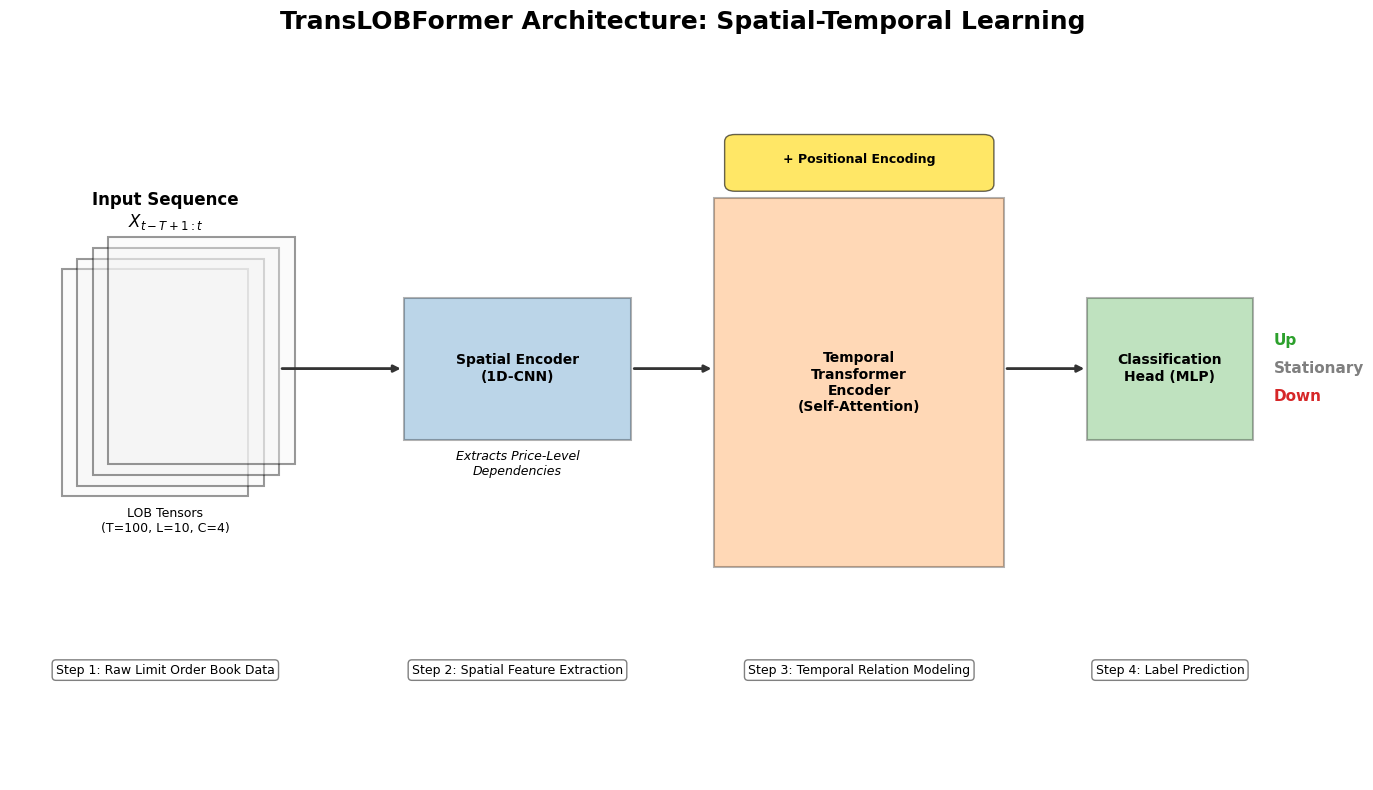

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_architecture():
    # Set style to a clean professional look
    plt.rcParams['font.family'] = 'sans-serif'
    fig, ax = plt.subplots(figsize=(14, 8))
    ax.set_xlim(0, 13)
    ax.set_ylim(0, 10)
    ax.axis('off')

    # Helper function for drawing boxes
    def add_box(x, y, w, h, label, color, alpha=0.4):
        rect = patches.Rectangle((x, y), w, h, linewidth=1.5, edgecolor='black', facecolor=color, alpha=alpha)
        ax.add_patch(rect)
        if label:
            ax.text(x + w/2, y + h/2, label, ha='center', va='center', fontweight='bold', fontsize=10)

    # 1. INPUT DATA (LOB Tensors)
    for i in range(4): # Visualizing the temporal stack
        add_box(0.5 + (i*0.15), 4 + (i*0.15), 1.8, 3.2, "", "whitesmoke")
    ax.text(1.5, 7.8, "Input Sequence\n$X_{t-T+1:t}$", ha='center', fontsize=12, fontweight='bold')
    ax.text(1.5, 3.5, "LOB Tensors\n(T=100, L=10, C=4)", ha='center', fontsize=9)

    # Arrow to CNN
    ax.annotate('', xy=(3.8, 5.8), xytext=(2.6, 5.8), arrowprops=dict(arrowstyle='-|>', lw=2, color='#333333'))

    # 2. SPATIAL ENCODER (CNN)
    add_box(3.8, 4.8, 2.2, 2, "Spatial Encoder\n(1D-CNN)", "#1f77b4", alpha=0.3)
    ax.text(4.9, 4.3, "Extracts Price-Level\nDependencies", ha='center', fontsize=9, style='italic')

    # Arrow to Transformer
    ax.annotate('', xy=(6.8, 5.8), xytext=(6.0, 5.8), arrowprops=dict(arrowstyle='-|>', lw=2, color='#333333'))

    # 3. TEMPORAL TRANSFORMER
    # Main Block
    add_box(6.8, 3.0, 2.8, 5.2, "Temporal\nTransformer\nEncoder\n(Self-Attention)", "#ff7f0e", alpha=0.3)

    # Corrected Positional Encoding indicator
    pe_rect = patches.FancyBboxPatch((7.0, 8.4), 2.4, 0.6, boxstyle="round,pad=0.1", fc="gold", ec="black", alpha=0.6)
    ax.add_patch(pe_rect)
    ax.text(8.2, 8.7, "+ Positional Encoding", ha='center', fontsize=9, fontweight='bold')

    # 4. PREDICTION HEAD
    ax.annotate('', xy=(10.4, 5.8), xytext=(9.6, 5.8), arrowprops=dict(arrowstyle='-|>', lw=2, color='#333333'))
    add_box(10.4, 4.8, 1.6, 2, "Classification\nHead (MLP)", "#2ca02c", alpha=0.3)

    # OUTPUT LABELS
    output_y = [6.2, 5.8, 5.4]
    labels = ["Up", "Stationary", "Down"]
    colors = ["#2ca02c", "#7f7f7f", "#d62728"]
    for y, label, color in zip(output_y, labels, colors):
        ax.text(12.2, y, label, fontsize=11, color=color, fontweight='bold', va='center')

    # Legend/Workflow annotations
    ax.text(1.5, 1.5, "Step 1: Raw Limit Order Book Data", ha='center', fontsize=9, bbox=dict(facecolor='none', edgecolor='gray', boxstyle='round'))
    ax.text(4.9, 1.5, "Step 2: Spatial Feature Extraction", ha='center', fontsize=9, bbox=dict(facecolor='none', edgecolor='gray', boxstyle='round'))
    ax.text(8.2, 1.5, "Step 3: Temporal Relation Modeling", ha='center', fontsize=9, bbox=dict(facecolor='none', edgecolor='gray', boxstyle='round'))
    ax.text(11.2, 1.5, "Step 4: Label Prediction", ha='center', fontsize=9, bbox=dict(facecolor='none', edgecolor='gray', boxstyle='round'))

    plt.title("TransLOBFormer Architecture: Spatial-Temporal Learning", fontsize=18, fontweight='bold', pad=30)
    plt.tight_layout()
    plt.savefig("translobformer_corrected.png", dpi=300, bbox_inches='tight')
    plt.show()

draw_architecture()

In [ ]:
import os
import math
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import f1_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset, ConcatDataset

# --- Config ---
BASE_PATH = "/content/drive/MyDrive/Colab Notebooks/Final_project/"
ASSET_IDS = range(1, 10)
MODEL_SAVE_PATH = "best_combined_adj_model.pth"
SAMPLE_SIZE, FEATURE_NUM, TARGET_NUM, HORIZON_INDEX = 100, 40, 5, 4
BATCH_SIZE, EPOCHS, LEARNING_RATE, PATIENCE = 128, 30, 1e-4, 5  # Adjusted Epochs and Patience
LAMBDA_CONTRASTIVE, D_MODEL, D_SPATIAL = 0.1, 32, 64

# --- Data Handling ---
class AssetDataset(Dataset):
    def __init__(self, feats, labels, sample_size):
        self.feats, self.labels = torch.from_numpy(feats).float(), torch.from_numpy(labels).long()
        self.S = sample_size
    def __len__(self): return len(self.feats) - self.S
    def __getitem__(self, idx):
        return self.feats[idx:idx+self.S], self.labels[idx+self.S-1]

def load_and_combine_assets(asset_ids, mode="Train"):
    all_ds = []
    for aid in asset_ids:
        path = f"{BASE_PATH}{mode}_Dst_NoAuction_ZScore_CF_{aid}.txt"
        df = pd.read_csv(path, sep='\s+', header=None).T
        feats_raw = df.values[:, :FEATURE_NUM]
        labels = df.values[:, -TARGET_NUM + HORIZON_INDEX].astype(np.int64) - 1
        std = feats_raw.std(0, keepdims=True); std[std == 0] = 1.0
        feats = (feats_raw - feats_raw.mean(0, keepdims=True)) / std
        all_ds.append(AssetDataset(feats.reshape(-1, 10, 4).astype(np.float32), labels, SAMPLE_SIZE))
    return ConcatDataset(all_ds)

# --- Model Components ---
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).float().unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2], pe[:, 1::2] = torch.sin(pos * div), torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x): return x + self.pe[:, :x.size(1)]

class SpatialEncoder(nn.Module):
    def __init__(self, n_features=4, hidden=32, d_spatial=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(n_features, hidden, 3, padding=1), nn.BatchNorm1d(hidden), nn.ReLU(),
            nn.Conv1d(hidden, hidden, 3, padding=1), nn.BatchNorm1d(hidden), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.fc = nn.Linear(hidden, d_spatial)
    def forward(self, x): return self.fc(self.net(x.permute(0, 2, 1)).squeeze(-1))

class TransLOBFormerAdj(nn.Module):
    def __init__(self, d_model=32, d_spatial=64, nhead=4, num_layers=3, num_classes=3):
        super().__init__()
        self.d_model = d_model
        self.spatial = SpatialEncoder(d_spatial=d_spatial)
        self.proj = nn.Linear(d_spatial, d_model)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_encode = PositionalEncoding(d_model, SAMPLE_SIZE + 1)
        self.transformer = nn.TransformerEncoder(nn.TransformerEncoderLayer(d_model, nhead, batch_first=True), num_layers)
        self.inf_A = nn.Linear(d_model, d_model * 8); self.inf_B = nn.Linear(d_model, d_model * 8)
        self.head = nn.Sequential(nn.Linear(d_model, d_model), nn.ReLU(), nn.Linear(d_model, num_classes))
        self.proj_x, self.proj_z = nn.Linear(d_model, d_model), nn.Linear(d_model, d_model)
        nn.init.normal_(self.cls_token, std=0.02)

    def forward(self, x):
        B, S, L, Fdim = x.shape
        tokens = self.proj(self.spatial(x.reshape(B*S, L, Fdim))).view(B, S, -1)
        x = self.pos_encode(torch.cat((self.cls_token.expand(B, -1, -1), tokens), dim=1))
        feat = self.transformer(x); cls_rep = feat[:, 0, :]
        A, B_mat = self.inf_A(cls_rep).view(B, self.d_model, 8), self.inf_B(cls_rep).view(B, self.d_model, 8)
        adj = torch.sigmoid(torch.bmm(A, B_mat.transpose(1, 2)) / math.sqrt(8))
        adj = (adj + torch.eye(self.d_model, device=adj.device)) / (adj.sum(-1, keepdim=True) + 1e-6)
        cls_ref = cls_rep + 0.3 * torch.bmm(adj, cls_rep.unsqueeze(-1)).squeeze(-1)
        return self.head(cls_ref), cls_ref, feat[:, 1:, :].mean(dim=1)

    def contrastive_loss(self, cls_rep, pooled):
        z, x = F.normalize(self.proj_z(cls_rep), dim=-1), F.normalize(self.proj_x(pooled), dim=-1)
        return F.cross_entropy((z @ x.T) / 0.1, torch.arange(len(z), device=z.device))

# --- Training Utilities ---
def evaluate(model, loader, device):
    model.eval()
    t_loss, t_corr, n = 0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            out, _, _ = model(xb)
            t_loss += F.cross_entropy(out, yb).item() * yb.size(0)
            t_corr += (out.argmax(1) == yb).sum().item()
            n += yb.size(0)
    return t_loss/n, t_corr/n

# --- Main Logic ---
device = "cuda" if torch.cuda.is_available() else "cpu"
train_loader = DataLoader(load_and_combine_assets(ASSET_IDS, "Train"), BATCH_SIZE, shuffle=True)
test_full = load_and_combine_assets(ASSET_IDS, "Test")
mid = len(test_full) // 2
val_loader = DataLoader(Subset(test_full, range(0, mid)), BATCH_SIZE*2)
test_loader = DataLoader(Subset(test_full, range(mid, len(test_full))), BATCH_SIZE*2)

model = TransLOBFormerAdj().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-2)

print("\n--- Starting Training with Early Stopping ---")
best_acc, patience_counter = 0.0, 0



for epoch in range(1, EPOCHS + 1):
    model.train()
    tot_acc, count = 0, 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch:02d}", leave=False)
    for xb, yb in pbar:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out, cls, pooled = model(xb)
        loss = F.cross_entropy(out, yb) + LAMBDA_CONTRASTIVE * model.contrastive_loss(cls, pooled)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        acc = (out.argmax(1) == yb).float().mean().item()
        tot_acc += acc * yb.size(0); count += yb.size(0)
        pbar.set_postfix({'Acc': f'{acc:.3f}', 'Loss': f'{loss.item():.4f}'})

    v_loss, v_acc = evaluate(model, val_loader, device)
    # Tweak: Exact print format from your example
    print(f"Epoch {epoch:02d} | Train Acc {tot_acc/count:.3f} | Val Acc: {v_acc:.4f}")

    if v_acc > best_acc:
        best_acc, patience_counter = v_acc, 0
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
    else:
        patience_counter += 1
    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch}.")
        break

print("\n--- Final Evaluation ---")
if os.path.exists(MODEL_SAVE_PATH): model.load_state_dict(torch.load(MODEL_SAVE_PATH))
t_loss, t_acc = evaluate(model, test_loader, device)

# Tweak: Updated to show Final Test Accuracy clearly
print(f"Final Test Loss: {t_loss:.4f}")
print(f"Final Test Accuracy: {t_acc:.4f}")

<>:33: SyntaxWarning: invalid escape sequence '\s'
<>:33: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-4069510925.py:33: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(path, sep='\s+', header=None).T



--- Starting Training with Early Stopping ---


Epoch 01 | Train Acc 0.532 | Val Acc: 0.6307


Epoch 02 | Train Acc 0.652 | Val Acc: 0.6734


Epoch 03 | Train Acc 0.689 | Val Acc: 0.7059


...

Epoch 20 | Train Acc 0.839 | Val Acc: 0.8431


Epoch 21 | Train Acc 0.843 | Val Acc: 0.8473


Epoch 22 | Train Acc 0.846 | Val Acc: 0.8503


Epoch 23 | Train Acc 0.849 | Val Acc: 0.8557


Epoch 24:  35%|███▍      | 4589/13199 [04:02<07:33, 18.97it/s, Acc=0.859, Loss=0.4488]